### Посмотри
### Библиотека [JAX ](https://docs.jax.dev/en/latest/) аналог PyTorch
### Офигенная книжка [NICOL `O CESA-BIANCHI "Prediction, Learning, and Games"](https://www.researchgate.net/publication/220690817_Prediction_Learning_and_Games)

### Суперская лекция [Ю. Дорн](https://)

# ЧТО НАС ЖДЕТ

* Perfect expert
* Inperfect expert
* Weighted average predictions
* Regret of polynomially-weighted average forecaster

In [1]:
import jax
import jax.numpy as jnp
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from functools import partial
import numpy as np

In [2]:
%config InlineBackend.figure_format = "retina"

key = jax.random.PRNGKey(314)

### Perfect expert
0) The **predictions** of the experts are binary valued: **{0,1}**

1) In this example, we assume that, given **$E$ number of experts**, there is one which predicts **the oracle 100%** of the times.

2) **At time $t=0$, we assign a weight of $1$** for each expert e: $w_{e, 0} = 1$ $\forall e \in \{1,\ldots, E\}$.

3) A prediction at time $t$ is given by
$$
    \hat y_t = \mathbb{1}\left(\frac{\sum_{e=1}^E w_{e,t-1}f_{e,t-1}}{\sum_{e=1}^E w_{e,t-1}} \geq \frac{1}{2} \right),
$$

Predict $1$ if at least half of all **active** experts predicted $1$. If the forecast is incorrect, i.e., $\hat y_t \neq y_t$, **we assign a weight of $0$ to all the experts who predicted incorrectly**.

###  *----------------------------Такой подход применим в случае "Imperfect expert"?---------------------------*
###.
###.

4) $W_m$ - the number of *active* experts after the forecaster has made $m$ mistakes. **At the $m$-th error, at least half of the experts that have been correct so far make their first misake**, i.e., $W_m \leq W_{m-1} / 2$.

### *Почему отсеивается как минимум половина экспертов после неверного предсказания?------------------------------------------------------------------------------------------------------*
###.
###.

### --------------------------- *Какая в этом случае оценка на REGRET?--------------------------------*
###.
###.

5) **The total number of errors is bounded by $\log_2(E)$**

*proof*

We have that
$W_m \leq W_{m-1} / 2 \leq W_{m-2} / 2 ^2 \ldots\ \leq W_0 / 2 ^ m = E / 2^m$

Since there exits at least one perfect expert, we have that
$$
    1 \leq W_m \leq E / 2^m.
$$


Solving for $m$, we find that
$$
    m \leq \log_2(E),
$$

*end proof*


In [3]:
def step(state, xs, update_fn):
    """
    At every timestep we compute the compute the
    predicted expert choice based on the still-credible
    experts. We then update the weights only if the aggregate
    prediction is the true prediction

    state: weights, n_errors
    xs: experts, y
    update_fn: Function to update the weights
    """
    weights, n_errors = state
    experts, y = xs

    expert_choice = (weights * experts).sum() / weights.sum()
    expert_choice = round(expert_choice) == y

    # Update the weights only if the forecast is erroneous
    weights, n_errors = jax.lax.cond(expert_choice,
        lambda *_: (weights, n_errors),
        update_fn,
        y, weights, experts, n_errors
    )

    out = {
        "weights": weights,
        "n_errors": n_errors,
    }

    new_state = (weights, n_errors)
    return new_state, out

### An empirical test

In [4]:
def update_weights(y, weights, experts, n_errors):
    """
    We filter where the choice of an expert aligns
    with the true value only if the expert has not already
    a mistake in the past
    """
    filter_experts = experts == y
    weights = filter_experts * weights
    return weights, n_errors + 1

In [5]:
key_oracle, key_experts = jax.random.split(key)
n_experts = 2 ** 5
n_timesteps = 100
true_expert_where = 10

oracle = jax.random.bernoulli(key_oracle, p=0.5, shape=(n_timesteps,))
experts = jax.random.bernoulli(key_experts, p=0.5, shape=(n_timesteps, n_experts))

# Insert the one true expert to the list of forecasters
experts = jnp.insert(experts, true_expert_where, oracle, axis=1)

In [6]:
w_init = jnp.ones(n_experts + 1)
state_init = (w_init, 0)
xs = (experts, oracle)

step_part = partial(step, update_fn=update_weights)

(w_last, n_errors), hist = jax.lax.scan(step_part, state_init, xs)

weights_hist = hist["weights"]

In [7]:
state_init

(Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],      dtype=float32),
 0)

In [8]:
xs

(Array([[False,  True,  True, ..., False, False, False],
        [False, False,  True, ...,  True, False,  True],
        [ True, False, False, ..., False, False, False],
        ...,
        [ True,  True,  True, ..., False, False,  True],
        [False, False,  True, ...,  True, False, False],
        [ True,  True,  True, ...,  True, False, False]], dtype=bool),
 Array([False, False, False, False, False, False, False, False,  True,
        False,  True, False, False,  True,  True,  True, False,  True,
         True,  True,  True, False, False,  True, False,  True, False,
         True,  True,  True,  True,  True,  True, False, False,  True,
         True,  True, False, False,  True,  True,  True, False,  True,
         True, False,  True,  True,  True,  True,  True,  True, False,
        False, False,  True,  True,  True, False, False,  True, False,
         True,  True,  True,  True, False, False,  True,  True,  True,
         True,  True,  True, False, False,  True, False,  True,

In [9]:
# Total number of errors
n_errors

Array(4, dtype=int32, weak_type=True)

In [10]:
# Theoretical upper bound
jnp.floor(jnp.log2(n_experts))

Array(5., dtype=float32)

#### Evolution of game

In [11]:
hist["n_errors"]

Array([0, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype=int32, weak_type=True)

### Тогда как ведет себя число активных экспертов?

In [12]:
# Number of active experts
weights_hist.sum(axis=1)

Array([33., 15.,  7.,  7.,  7.,  7.,  3.,  3.,  3.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.], dtype=float32)

## Imperfect expert

1) In this example, we assume that there exits an expert that is **correct most of the times**.

2) If a forecaster makes a mistake at time $t$, we **discount each expert** who was wrong by a dicsount factor $\beta\in(0,1)$ : $w_k \gets \beta w_k$.

3) At the time the forecaster makes its $m$-th mistake, the total weight of the forecaster is at most $W_{m-1} /2$ (for all experts who were not discounted) plus $\beta W_{m-1}/2$ (for all experts who made a mistake and were discounted).

4) We obtain

$W_m \leq W_{m-1} / 2 + \beta W_{m-1} /2 = W_{m-1}[1 + \beta] / 2 \leq$

$ \leq \left(W_{m-2} / 2 + \beta W_{m-2} / 2 \right)[1 + \beta] / 2 = W_{m-2} [1 + \beta]^2 / 2^2 \ldots$

$\ldots \leq W_0 [1 + \beta]^m / 2^m = E [1 + \beta]^m / 2^m $

5) Let *$k$* be the index of the expert who makes **the fewest mistakes** ($m^*$), when the forecaster has made $m$ mistakes. Then **its weight** $w_k = \beta^{m^*}$.

Note that $W_m \geq w_k = \beta^{m^*}$. We obtain
\begin{aligned}
    \beta^{m^*} \leq W_m = E[1 + \beta]^m / 2^m
\end{aligned}

So that
$$
\begin{aligned}
    m^* \log_2\beta &\leq \log_2 E + m\log_2(1 + \beta) - m\log_2 2\\
    &= \log_2 E + m(\log_2(1 + \beta) - 1).
\end{aligned}
$$

Solving for $m$, we obtain
$$
\begin{aligned}
m \leq \frac{m^*\log_2\beta - \log_2 E}{\log_2(1 + \beta) - 1}
\end{aligned}
$$

In [13]:
def update_weights_beta(y, weights, experts, n_errors, beta):
    """
    We filter where the choice of an expert aligns
    with the true value only if the expert has not already
    a mistake in the past
    """
    filter_experts = experts != y
    weights = jnp.exp(filter_experts * jnp.log(beta)) * weights

    return weights, n_errors + 1

In [14]:
key = jax.random.PRNGKey(314)

key_oracle, key_experts, key_noise = jax.random.split(key, 3)

n_experts = 2 ** 6
n_timesteps = 5_000
true_expert_where = 10

beta = 0.9
oracle = jax.random.bernoulli(key_oracle, p=0.5, shape=(n_timesteps,))
experts = jax.random.bernoulli(key_experts, p=0.5, shape=(n_timesteps, n_experts))


p_mistake = 0.05
mistakes = jax.random.bernoulli(key_noise, p=p_mistake, shape=(n_timesteps,))
true_expert  = oracle ^ mistakes # Flip bit if mistake

# Insert the one true expert to the list of experts
experts = jnp.insert(experts, true_expert_where, true_expert, axis=1)

min_errors = (true_expert != oracle).cumsum()

In [15]:
import numpy as np
a = np.array([0,1,1,0,1])
b = np.array([1,0,1,0,1])

In [16]:
a ^ b

array([1, 1, 0, 0, 0])

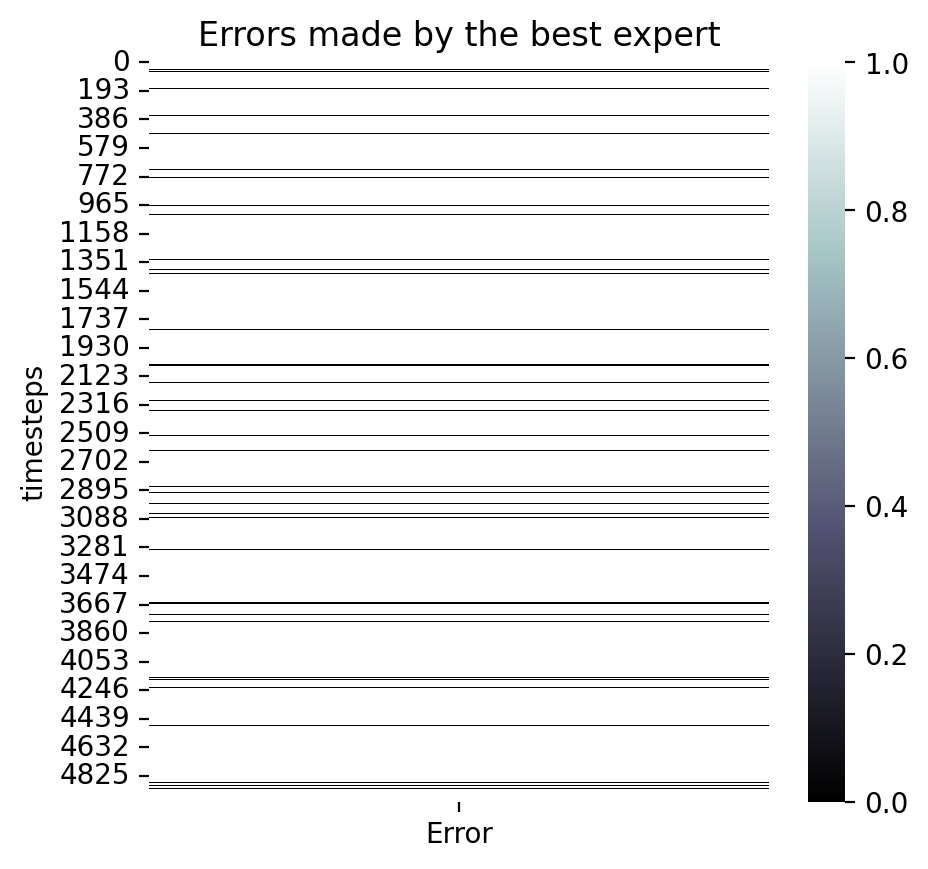

In [17]:
fig, ax = plt.subplots(figsize=(5, 4.8))
sns.heatmap(jnp.c_[oracle == true_expert], cmap="bone", xticklabels=["Error"], ax=ax)
plt.title("Errors made by the best expert")
plt.ylabel("timesteps");

In [18]:
w_init = jnp.ones(n_experts + 1)
state_init = (w_init, 0)
xs = (experts, oracle)

part_update_fn = partial(update_weights_beta, beta=beta)
step_part = partial(step, update_fn=part_update_fn)
(w_last, n_errors), hist = jax.lax.scan(step_part, state_init, xs)
weights_hist = hist["weights"]

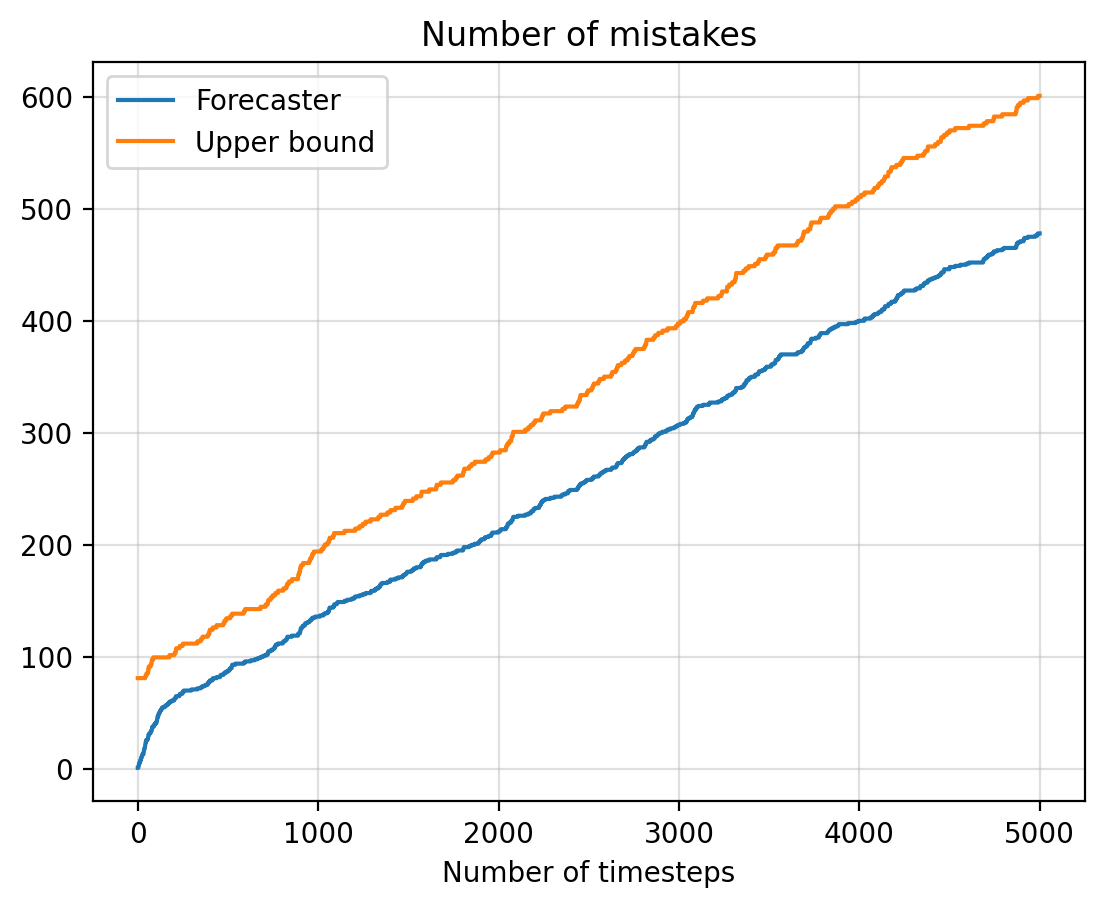

In [19]:
mistakes_ubound = (jnp.log2(n_experts) + min_errors * jnp.log2(1 / beta)) / (jnp.log2(2) - jnp.log2(1 + beta))
# mistakes_ubound = (min_errors * jnp.log2(beta) - jnp.log2(n_experts)) / (jnp.log2(1 + beta) - 1)

plt.plot(hist["n_errors"], label="Forecaster")
plt.plot(mistakes_ubound, label="Upper bound")
plt.legend()
plt.title("Number of mistakes")
plt.xlabel("Number of timesteps")
plt.grid(alpha=0.4)

### Multiple $\beta$-values

In [20]:
@partial(jax.vmap)
def vmap_eval_algo(beta):
    w_init = jnp.ones(n_experts + 1)
    state_init = (w_init, 0)
    xs = (experts, oracle)

    part_update_fn = partial(update_weights_beta, beta=beta)
    step_part = partial(step, update_fn=part_update_fn)
    (w_last, n_errors), hist = jax.lax.scan(step_part, state_init, xs)
    return hist["n_errors"]

In [21]:
n_betas = 30
beta_values = jnp.linspace(0.01, 1, n_betas)
hist_betas = vmap_eval_algo(beta_values)

cmap = plt.cm.RdBu_r
colors = cmap(jnp.linspace(0, 1, n_betas))

norm = mpl.colors.Normalize(vmin=min(beta_values), vmax=max(beta_values))
cmappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

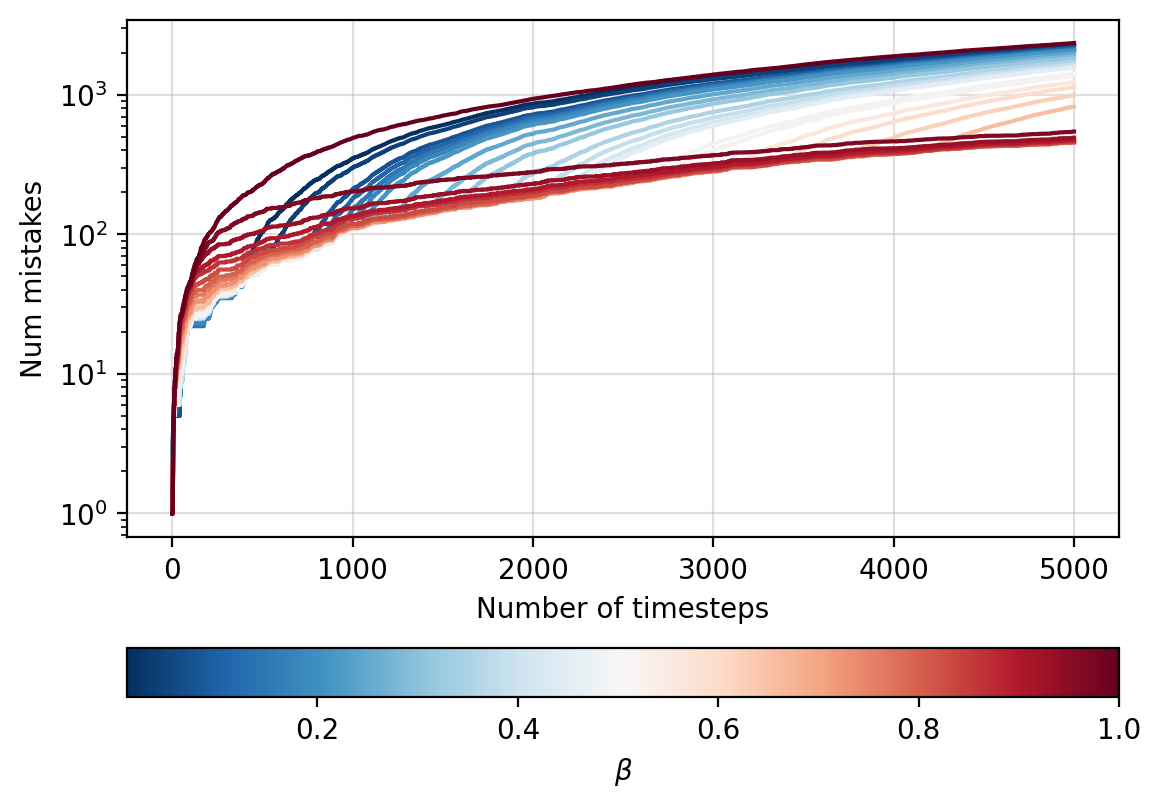

In [22]:
fig, ax = plt.subplots()
for hist, c in zip(hist_betas, colors):
    ax.plot(hist, c=c)

ax.set_yscale("log")
ax.set_ylabel("Num mistakes")
ax.set_xlabel("Number of timesteps")
fig.colorbar(cmappable, ax=ax, orientation="horizontal", label=r"$\beta$")
ax.grid(alpha=0.4)

In [23]:
import jax
from functools import partial


@partial(jax.vmap, in_axes=(0, 0, None), out_axes=-1)
def _create_mistakes(key, p, T):
    mistakes = jax.random.bernoulli(key, p=p, shape=(T,))
    return mistakes


def bern_oracle_beta_forecasters(key, n_experts, n_timesteps, a_fcst=2, b_fsct=7, p_oracle=0.5):
    """
    Create a set of forecasters whose probability of being correct is
    distributed according to a Beta(a_fcst, b_fcst) distribution.
    The oracle is a Bernoulli random variable with p=p_oracle.
    """
    key_oracle, key_noise, key_errs = jax.random.split(key, 3)
    keys_noise = jax.random.split(key_noise, n_experts)

    oracle = jax.random.bernoulli(key_oracle, p=p_oracle, shape=(n_timesteps,))
    ps_mistakes = jax.random.beta(key_errs, a=a_fcst, b=b_fsct, shape=(n_experts,))

    mistakes = _create_mistakes(keys_noise, ps_mistakes, n_timesteps)
    experts = (mistakes ^ oracle[:, None]).astype(float)

    return oracle, experts


# Weighted average predictions
A prediction with expert advice is done considering
* A decision space $\cal D$,
* an outcome space $\cal y$,
* A loss function $\ell$, and
* a set of $\cal E$ of experts indices

For each round $t=1,2,\ldots$
. The environment chooses the next outcome $y_t$ and the expert advice $\{f_{e,t} \in {\cal D}: e \in {\cal E}\}$;
2. The forecaster chooses the prediction $\hat{p}_t \in {\cal D}$;
3. The environmente reveals the next outcome $y_t \in {\cal Y}$;
4. the forecaster incurs loss $\ell(\hat p_t, y_t)$ and each expert $e$ incurs loss $\ell(f_{e,t}, y_t)$


### -----------*Как ведет себя лосс, если предсказание правильное?*-----------

# The weighted average forecaster
### Regret
1) The forecaster's goal is to keep as small as possible cumulative regret. For **expert** $e$, this quantity is defined by

$$
    R_{e,T} = \sum_{t=1}^T\left(\ell(\hat p_t, y_t)  - \ell(f_{e, t}, y_t)\right) = \hat L_T - L_{e, T}.
$$

### -----------*Что происходит с весом эксперта (e) если $R_{e,T}$ - становится больше?*-----------
###.
###.
2) Hence, we **view the weight as an arbitrary increasing function** of the expert's regret. This function is **the derivative of** a nonnegative, **convex**, and increasing function**: $\phi: \mathbb{R} -> \mathbb{R}$

3) The **forecaster uses $\phi '$ to determine the weight  assigned to the $i^{th}$ expert:** $$w_{i,t-1} = \phi '(R_{i,t−1})$$

### -----------*Почему это возрастающая функция?*-----------
###.
###.

4) Therefore, the **prediction** $\hat p_t$ at time $t$ of the weighted average forecaster is defined by:


$$
    \hat p_t = \frac{\sum_{i=1}^N \phi'(R_{i,t-1}) f_{i,t}}{\sum_{j=1}^N \phi'(R_{j, t-1})}
$$

### A forecaster based on the potential $\Phi$.

5) Using the notion of potential function, we give the following definition of the weighted average forecaster

$$
    \hat p_t = \frac{\sum_{e=1}^E \nabla\Phi(R_{t-1})_e f_{e,t}}{\sum_{e=1}^E \nabla\Phi(R_{t-1})_e}
$$

### -----------Отличаются ли *$\phi'(R_{e,t-1})$ и $\nabla\Phi(R_{t-1})_e$?*-----------
###.
###.

###----------**УГУ, ведь** $\Phi(u) = \psi (\sum_{i=1}^N \phi(u_i))$. Но почему тогда законно 4) -> 5)?-------

###.
###.

6) function $\psi $ is:
* nonnegative
* strictly increasing
* concave
* twice differentiable auxiliary function

### Polynomially-weighted average forecaster

7) We consider the polynomially-weighted average forecaster based on the potential

$$
    \Phi_p({\bf u}) = \left(\sum_{e=1}^E (u_e)_+^p\right)^{2/p} = ||{\bf u}_+||_{p}^2
$$

###---------- В этом примере на шаге $t$
###----------(1)$\psi(x) = ?$, (2)$\phi(\mathbf x) = ?$, (3)$u_e = ?$, (4)$w_{e,t} = ?$
###.
###.
###.
$\psi(u) = u^{2/p}$

$\phi(u) = u_{+}^{p}$

$u_e = R_{e,t} = \sum_{s=1}^{t}\left(\ell(\hat p_s, y_s)  - \ell(f_{e, s}, y_s)\right)$

$w_{e,t} = \nabla\Phi(\mathbf{R}_{t})_e = \frac{2}{p||(\mathbf{R}_{t})_+||_p^{p-2}} \cdot p (R_{e,t})_+^{p-1} = \frac{2(R_{e,t})_+^{p-1}}{||(\mathbf{R}_{t})_+||_p^{p-2}}$

Although $\nabla\Phi_p$ is relatively straighforward to compute, we make use of `jax.grad` for simplicity.



In [24]:
def loss(yhat, y):
    return (yhat - y) ** 2


def potential(x, p):
    xhat = jnp.maximum(0, x)
    return jnp.linalg.norm(xhat, p) ** 2


@partial(jax.vmap, in_axes=(0, 0, None), out_axes=-1)
def create_mistakes(key, p, T):
    mistakes = jax.random.bernoulli(key, p=p, shape=(T,))
    return mistakes


gradp = jax.grad(potential)
# gradp(regret_prev, pnorm)


In [36]:
def forecast_step(experts_curr, regret_prev, pnorm):
    weights = gradp(regret_prev, pnorm)
    forecast = weights @ experts_curr / weights.sum()
    return weights, forecast


def step(regret, xs, pnorm):
    """
    At time t, we make a prediction based on the
    regret (as defined by the potential) obtained at time
    t-1 and the prediction of each forecaster at time t.

    After making a new prediction, we update the regret.
    """
    experts, oracle = xs
    weights, forecast = forecast_step(experts, regret, pnorm)

    loss_forecaster = loss(forecast, oracle)
    loss_experts = loss(experts, oracle)

    iregret_experts = loss_forecaster - loss_experts

    regret_new = regret + iregret_experts

    res = {
        "weights": weights,
        "forecast": forecast,
        "step-loss-experts": loss_experts,
        "step-loss-forecaster": loss_forecaster,
    }


    return regret_new, res

## Evaluating the forecaster
### Creating *stream* of data

In this example, we consider an oracle that takes decisions according to $y_t \sim \text{Bern}(\mu)$. We consider `n_experts` number of experts.  Each expert $e$ is correct $v_e \sim \text{Beta}(a, b)$ proportion of times.

In [37]:
key = jax.random.PRNGKey(314)

n_experts = 10
n_timesteps = 500
a, b = 2, 7
p_oracle = 0.5
pnorm = 2


oracle, experts = bern_oracle_beta_forecasters(key, n_experts, n_timesteps, a, b, p_oracle)

In [39]:
regret = jnp.ones(n_experts)
xs = (experts, oracle)
part_step = partial(step, pnorm=pnorm)
_, res = jax.lax.scan(part_step, regret, xs)

In [41]:
res["forecast"]

Array([0.1       , 0.33296698, 0.17225565, 0.3620979 , 0.10177409,
       0.05789197, 0.06189275, 0.        , 0.71103144, 0.0977893 ,
       0.60990626, 0.        , 0.        , 0.82867247, 1.        ,
       0.7891546 , 0.        , 1.        , 1.        , 1.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       1.        , 0.        , 1.        , 1.        , 1.        ,
       0.27643472, 1.        , 1.        , 0.47076967, 0.17386186,
       1.        , 1.        , 1.        , 0.        , 0.        ,
       1.        , 1.        , 1.        , 0.        , 1.        ,
       1.        , 0.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 0.        , 0.        ,
       0.        , 1.        , 1.        , 1.        , 0.22024542,
       0.        , 1.        , 0.        , 1.        , 1.        ,
       1.        , 1.        , 0.        , 0.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

In [28]:
L_experts = res["step-loss-experts"].cumsum(axis=0)
L_expert_min = L_experts.min(axis=1)
L_forecaster = res["step-loss-forecaster"].cumsum()

regret_forecaster = L_forecaster - L_expert_min

### Regret of polynomially-weighted average forecaster.
Assume that the loss function $l$ is convex in its first argument and that it takes values in [0,1]. Then, for any sequence $y_1, y_2,... \in Y$ of outcomes and for any $n \geq 1$, the regret of the polynomially weighted average forecaster satisfies $\hat L_n - \min\limits_{i =1,..., N} L_{i,n} \leq \sqrt{n(p−1)N^{2/p}}$.

In [44]:
L_forecaster

Array([1.0000001e-02, 1.2086701e-01, 1.5053901e-01, 2.8165388e-01,
       2.9201186e-01, 2.9536334e-01, 2.9919404e-01, 2.9919404e-01,
       3.8269687e-01, 3.9225963e-01, 5.4443276e-01, 5.4443276e-01,
       5.4443276e-01, 5.7378590e-01, 5.7378590e-01, 6.1824167e-01,
       6.1824167e-01, 6.1824167e-01, 6.1824167e-01, 6.1824167e-01,
       6.1824167e-01, 6.1824167e-01, 6.1824167e-01, 6.1824167e-01,
       6.1824167e-01, 6.1824167e-01, 6.1824167e-01, 6.1824167e-01,
       6.1824167e-01, 6.1824167e-01, 1.1417884e+00, 1.1417884e+00,
       1.1417884e+00, 1.3634125e+00, 1.3936404e+00, 1.3936404e+00,
       1.3936404e+00, 1.3936404e+00, 1.3936404e+00, 1.3936404e+00,
       1.3936404e+00, 1.3936404e+00, 1.3936404e+00, 1.3936404e+00,
       1.3936404e+00, 1.3936404e+00, 1.3936404e+00, 1.3936404e+00,
       1.3936404e+00, 1.3936404e+00, 1.3936404e+00, 1.3936404e+00,
       1.3936404e+00, 1.3936404e+00, 1.3936404e+00, 1.3936404e+00,
       1.3936404e+00, 1.3936404e+00, 1.3936404e+00, 1.4421484e

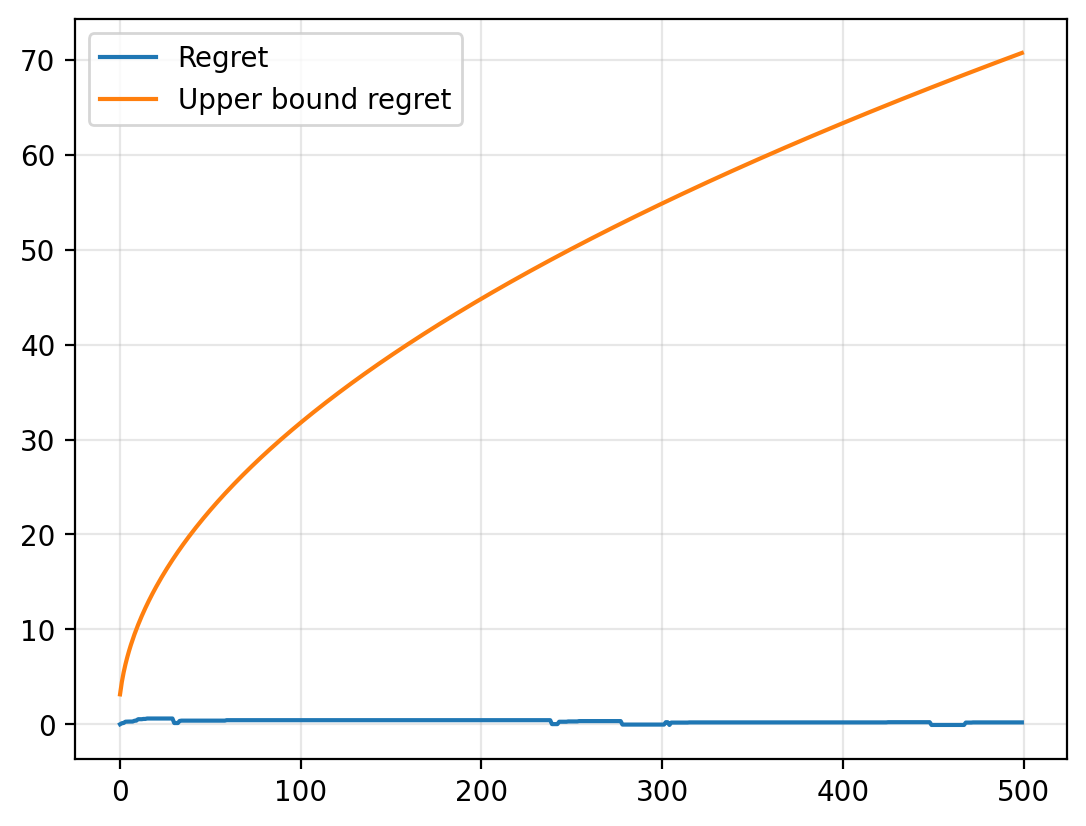

In [29]:
timesteps = np.arange(1, n_timesteps + 1)
ubound = np.sqrt(timesteps * (pnorm - 1) * n_experts ** (2 / pnorm))

plt.plot(regret_forecaster, label="Regret")
plt.plot(ubound, label="Upper bound regret")
plt.legend()
plt.grid(alpha=0.3)

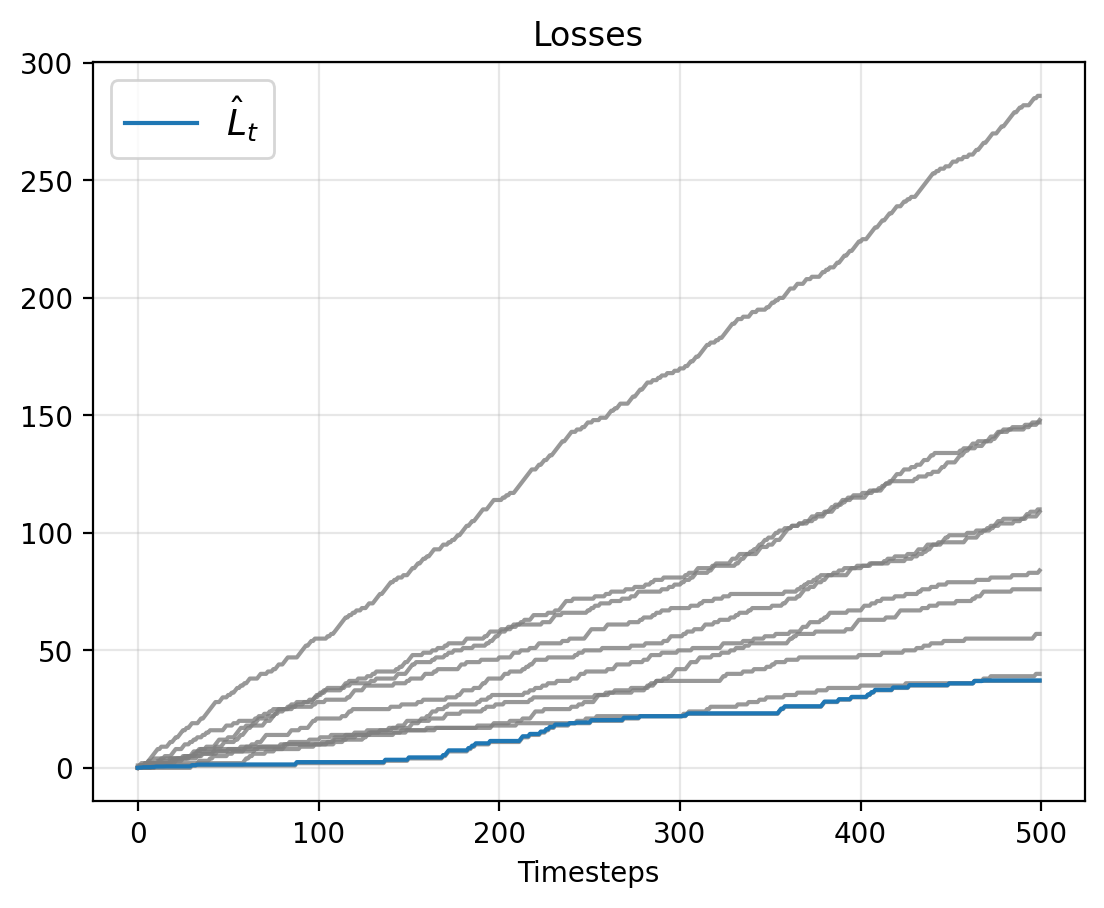

In [30]:
plt.plot(L_experts, c="tab:gray", alpha=0.8)
#plt.plot(L_expert_min, label=r"$\min\,L_{e,t}$")
plt.plot(L_forecaster, label=r"$\hat L_t$")
plt.title("Losses")
plt.legend(fontsize=13)
plt.xlabel("Timesteps")
plt.grid(alpha=0.3)

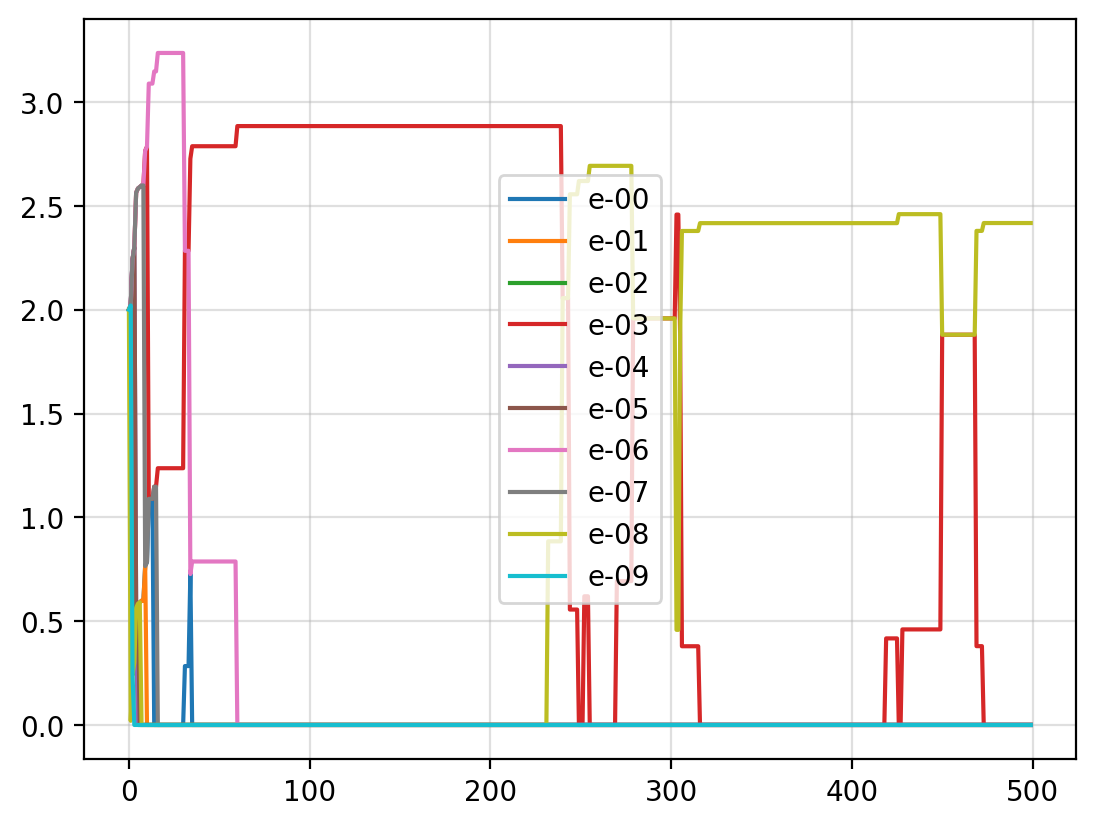

In [31]:
for e in range(n_experts):
    plt.plot(res["weights"][:, e], label=f"e-{e:02}")
plt.legend()
plt.grid(alpha=0.4);

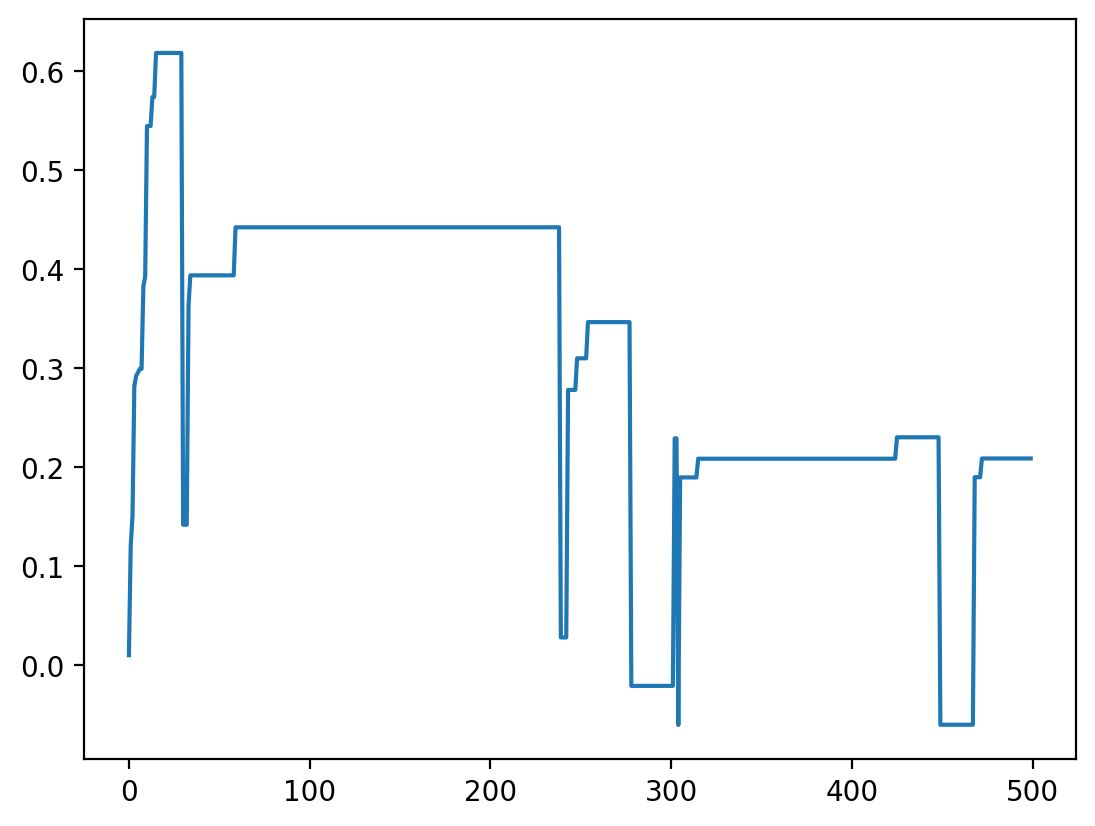

In [32]:
plt.plot(regret_forecaster)

#### Осталось вывести REGRET:

### Regret of polynomially-weighted average forecaster.
Assume that the loss function $l$ is convex in its first argument and that it takes values in [0,1]. Then, for any sequence $y_1, y_2,... \in Y$ of outcomes and for any $n \geq 1$, the regret of the polynomially weighted average forecaster satisfies $\hat L_n - \min\limits_{i =1,..., N} L_{i,n} \leq \sqrt{n(p−1)N^{2/p}}$.


#### Как будем действовать?


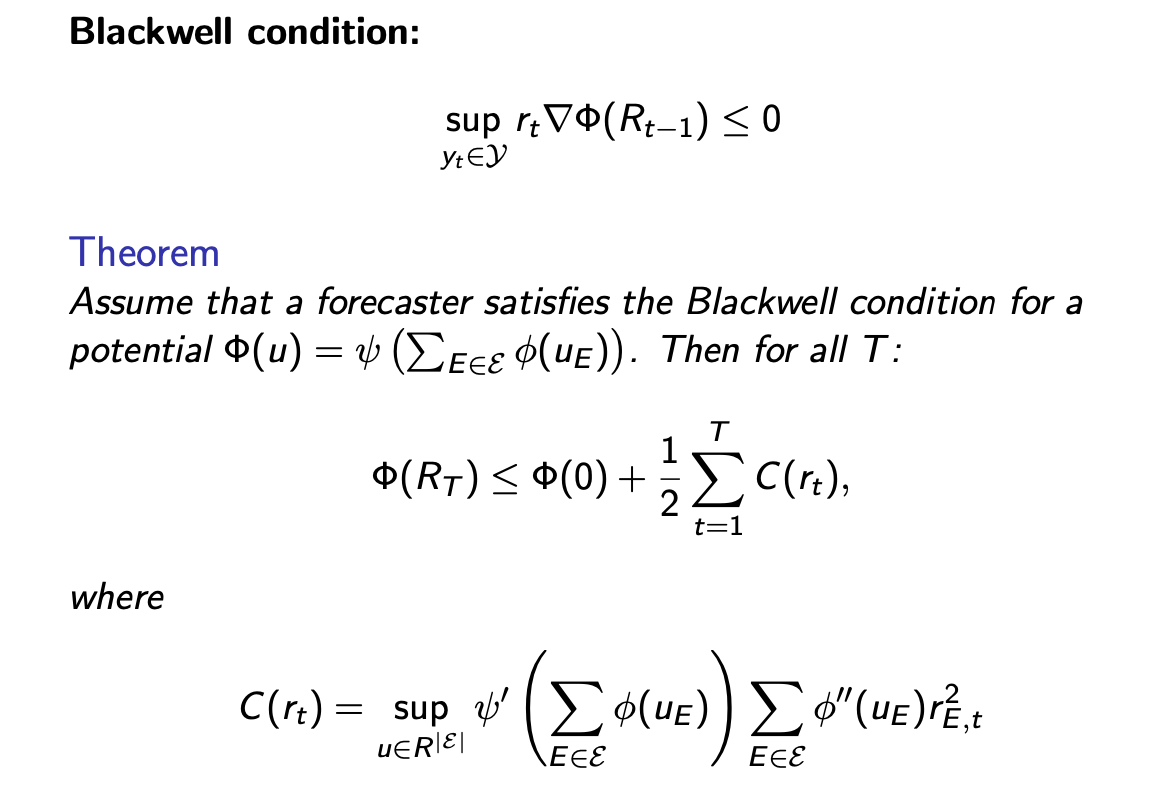